# 13. Microgrid: a flagship case study

An off-grid cabin must supply its daily energy and peak load without grid power. Four subsystems contribute:

- a **solar PV array** (cheap when the sun shines, but the sun is stochastic);
- a **lithium battery** with a discrete chemistry choice (LFP, NMC, LCO, NaIon);
- a **diesel generator** (reliable but carbon-heavy);
- a **structural frame** whose mass and cost scale with the total mass it must support, *including its own*, producing a genuine fixed-point coupling.

This notebook brings together every feature of the package: cyclic dependencies, parameter sweeps with solver warm-start, stochastic uncertainty on the sun, and the new visualisation helpers in `codesign.viz`.


## Modules

In [1]:
from codesign import Module, Reals, Stochastic, System, solve, viz
from scipy import stats
import numpy as np


class SolarArray(Module):
    # Required peak power is the larger of the user's stated peak demand
    # and the average daily-energy demand divided by available sun hours.
    # cost and mass scale linearly with this required peak (kW).
    F = {"peak_power_kw": Reals(unit="kW"),
         "daily_energy_kwh": Reals(unit="kWh")}
    R = {"cost_usd": Reals(unit="USD"), "mass_kg": Reals(unit="kg")}

    def __init__(self, cost_per_kw=1100.0, mass_per_kw=28.0,
                 sun_hours_per_day=3.0):
        self.cost_per_kw = cost_per_kw
        self.mass_per_kw = mass_per_kw
        self.sun_hours_per_day = sun_hours_per_day
        super().__init__()

    def h(self, f):
        # Guard against sun=0 (no sun, infinite array needed).
        sun = max(self.sun_hours_per_day, 1e-6)
        # Whichever constraint binds: instantaneous peak, or daily average.
        required_peak = max(f["peak_power_kw"],
                            f["daily_energy_kwh"] / sun)
        return {"cost_usd": required_peak * self.cost_per_kw,
                "mass_kg":  required_peak * self.mass_per_kw}


class Battery(Module):
    # Battery sized to storage demand. Four chemistries differ in specific
    # energy (Wh/kg), cost density (USD/kWh), and cycle life (equivalent
    # full-cycles before replacement). The catalogue is a static dict
    # rather than a CatalogDP since chemistry is a one-shot choice.
    F = {"storage_kwh": Reals(unit="kWh")}
    R = {"cost_usd": Reals(unit="USD"), "mass_kg": Reals(unit="kg"),
         "replacements": Reals()}
    CHEMISTRIES = {
        # name: (Wh/kg, USD/kWh, cycle life)
        "LFP":   (160.0, 130.0, 4000.0),
        "NMC":   (240.0, 175.0, 2000.0),
        "LCO":   (220.0, 180.0,  800.0),
        "NaIon": (110.0,  90.0, 3000.0),
    }
    def __init__(self, chemistry="LFP", daily_cycles=1.0, life_years=10.0):
        wh_kg, usd_kwh, life = self.CHEMISTRIES[chemistry]
        self.chemistry = chemistry
        self.specific_energy = wh_kg
        self.cost_density = usd_kwh
        self.cycle_life = life
        self.daily_cycles = daily_cycles
        self.life_years = life_years
        super().__init__()

    def h(self, f):
        kwh = f["storage_kwh"]
        # Number of replacements expected over the mission life.
        reps = (self.daily_cycles * 365.0 * self.life_years) / max(self.cycle_life, 1.0)
        return {"cost_usd": kwh * self.cost_density * (1.0 + reps),
                "mass_kg":  kwh * 1000.0 / max(self.specific_energy, 1e-6),
                "replacements": reps}


class DieselGenerator(Module):
    # Capital cost scales with kW capacity; fuel cost scales with kWh used
    # per month. CO2 emission likewise tracks kWh-per-month consumption.
    F = {"backup_power_kw": Reals(unit="kW"),
         "backup_hours":    Reals(unit="h")}
    R = {"cost_usd": Reals(unit="USD"), "mass_kg": Reals(unit="kg"),
         "co2_kg":   Reals(unit="kg")}
    def __init__(self, cost_per_kw=500.0, mass_per_kw=40.0,
                 fuel_cost_per_kwh=0.35, co2_per_kwh=0.95):
        self.cost_per_kw = cost_per_kw
        self.mass_per_kw = mass_per_kw
        self.fuel_cost_per_kwh = fuel_cost_per_kwh
        self.co2_per_kwh = co2_per_kwh
        super().__init__()
    def h(self, f):
        kw = f["backup_power_kw"]
        hrs = f["backup_hours"]
        kwh = kw * hrs
        capital = kw * self.cost_per_kw
        fuel = kwh * self.fuel_cost_per_kwh * 30.0  # 30 days/month
        return {"cost_usd": capital + fuel,
                "mass_kg":  kw * self.mass_per_kw,
                "co2_kg":   kwh * self.co2_per_kwh * 30.0}


class Frame(Module):
    # The frame mass is 18% of whatever it must support. Because the frame
    # supports itself too, this creates a self-referential constraint that
    # the Kleene iteration resolves.
    F = {"supported_mass_kg": Reals(unit="kg")}
    R = {"cost_usd": Reals(unit="USD"), "mass_kg": Reals(unit="kg")}
    def h(self, f):
        m = f["supported_mass_kg"] * 0.18
        return {"cost_usd": m * 6.0, "mass_kg": m}

## Building the system

The frame's mass depends on the total supported mass *including the frame itself*. The Kleene iteration handles this cycle automatically.


In [2]:
def make_microgrid(*, chemistry="LFP", sun_hours_per_day=3.0,
                   solar_fraction=0.85, uncertainty=False):
    solar = SolarArray(sun_hours_per_day=sun_hours_per_day)
    if uncertainty:
        solar.uncertain_dist = Stochastic(
            marginals={"sun_hours_per_day":
                stats.truncnorm(a=-1.5, b=1.5,
                                loc=sun_hours_per_day, scale=1.0)},
        )
    sys = System(f"microgrid_{chemistry}")
    daily_load = sys.provides("daily_load_kwh", unit="kWh")
    peak_load  = sys.provides("peak_load_kw",   unit="kW")
    backup_h   = sys.provides("backup_hours",   unit="h")
    total_cost = sys.requires("total_cost_usd", unit="USD")
    total_mass = sys.requires("total_mass_kg",  unit="kg")
    annual_co2 = sys.requires("annual_co2_kg",  unit="kg/yr")
    s = sys.add("solar",   solar)
    b = sys.add("battery", Battery(chemistry=chemistry))
    d = sys.add("diesel",  DieselGenerator())
    fr = sys.add("frame",  Frame())
    s.daily_energy_kwh >= daily_load * solar_fraction
    s.peak_power_kw    >= peak_load
    b.storage_kwh      >= daily_load * solar_fraction
    d.backup_power_kw  >= peak_load
    d.backup_hours     >= backup_h
    fr.supported_mass_kg >= s.mass_kg + b.mass_kg + d.mass_kg + fr.mass_kg
    total_cost >= s.cost_usd + b.cost_usd + d.cost_usd + fr.cost_usd
    total_mass >= s.mass_kg + b.mass_kg + d.mass_kg + fr.mass_kg
    annual_co2 >= d.co2_kg * (365.0 / 30.0)
    return sys.build()


mission = {"daily_load_kwh": 15.0, "peak_load_kw": 3.0, "backup_hours": 12.0}

## Compare the four chemistries

In [3]:
for chem in ["LFP", "NMC", "LCO", "NaIon"]:
    r = solve(make_microgrid(chemistry=chem), mission, max_iter=400)
    p = list(r.antichain.points)[0]
    print(f"{chem:<6} cost=${p['total_cost_usd']:>8.0f}  "
          f"mass={p['total_mass_kg']:>6.1f} kg  "
          f"CO2={p['annual_co2_kg']:>6.1f} kg/yr  "
          f"(iters={r.iterations})")

LFP    cost=$   10143  mass= 388.6 kg  CO2=12483.0 kg/yr  (iters=24)
NMC    cost=$   13241  mass= 356.2 kg  CO2=12483.0 kg/yr  (iters=24)
LCO    cost=$   19710  mass= 362.1 kg  CO2=12483.0 kg/yr  (iters=24)
NaIon  cost=$    9564  mass= 432.8 kg  CO2=12483.0 kg/yr  (iters=24)


A clear tradeoff: NaIon is cheapest but heaviest, LFP is the all-rounder, LCO is the priciest (short life means it pays for replacements). The frame's cyclic dependence forces the iteration to do real work; iteration counts in the 20-25 range are typical.

## Convergence trace with `viz.plot_convergence`

One call to render the delta-vs-iteration semilog.


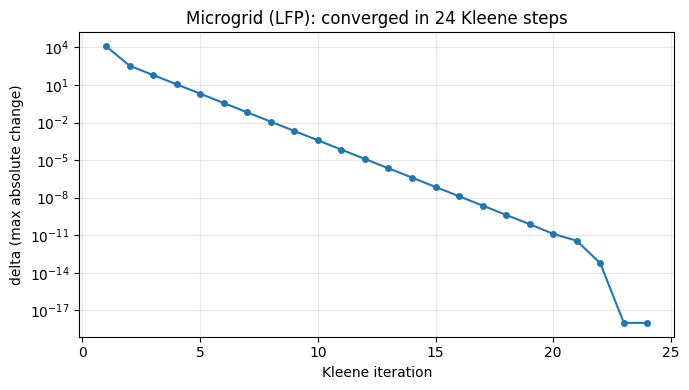

In [4]:
import matplotlib.pyplot as plt

dp = make_microgrid(chemistry="LFP")
r = solve(dp, mission, max_iter=400, trace=True)
ax = viz.plot_convergence(r)
ax.set_title(f"Microgrid (LFP): converged in {r.iterations} Kleene steps")
plt.tight_layout()
plt.show()

## Warm-started parameter sweep

Sweeping `daily_load_kwh` from 5 to 30 kWh in 50 steps. Warm-starting each solve from the previous fixed point saves Kleene iterations: the answer at 15.5 kWh is a good seed for 16.0 kWh.


In [5]:
dp = make_microgrid(chemistry="LFP")
loads = np.linspace(5.0, 30.0, 50)

# Cold sweep: each solve starts fresh from the bottom antichain.
cold_iters = 0
for L in loads:
    f = {"daily_load_kwh": float(L), "peak_load_kw": 3.0, "backup_hours": 12.0}
    r = solve(dp, f, max_iter=400)
    cold_iters += r.iterations

# Warm sweep: each solve reuses the previous fixed point as its seed.
# Since adjacent parameter values usually have nearby fixed points, the
# Kleene iteration finishes in fewer steps.
warm_iters = 0
prev = None
for L in loads:
    f = {"daily_load_kwh": float(L), "peak_load_kw": 3.0, "backup_hours": 12.0}
    r = solve(dp, f, max_iter=400, start_from=prev)
    warm_iters += r.iterations
    prev = r            # feed this result into the next iteration

print(f"cold total iters: {cold_iters}")
print(f"warm total iters: {warm_iters}")
print(f"speedup: {cold_iters / max(warm_iters, 1):.2f}x")

cold total iters: 1203
warm total iters: 1077
speedup: 1.12x


## Stochastic sun hours

The sun is treated as a truncated-normal random variable around 3 hours/day. A Monte-Carlo solve over 200 samples gives the cost distribution, plus mean, p95, CVaR95.


In [6]:
dp_u = make_microgrid(chemistry="LFP", uncertainty=True)
res_u = solve(dp_u, mission,
              uncertainty=["mean", "p95", "cvar95", "samples"],
              n_samples=200, rng_seed=42, max_iter=400)
nominal = solve(make_microgrid(chemistry="LFP"), mission, max_iter=400)
nominal_cost = list(nominal.antichain.points)[0]["total_cost_usd"]
print(f"Nominal cost: ${nominal_cost:.0f}")
print(f"Mean cost (MC): ${res_u.mean['total_cost_usd']:.0f}")
print(f"p95 cost: ${res_u.p95['total_cost_usd']:.0f}")
print(f"CVaR95 cost: ${res_u.cvar95['total_cost_usd']:.0f}")
print(f"Feasibility rate: {res_u.feasibility_rate:.3f}")

Nominal cost: $10143
Mean cost (MC): $10490
p95 cost: $13214
CVaR95 cost: $13909
Feasibility rate: 1.000


## Distribution plot with `viz.plot_uncertainty`

Histogram of cost across MC samples, with summary lines.


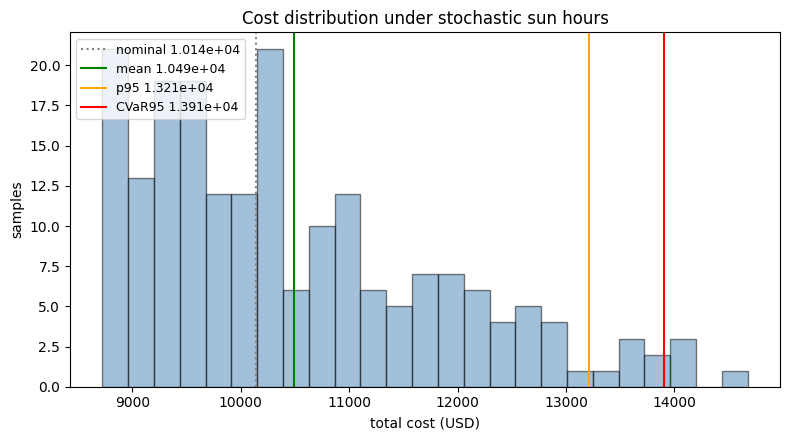

In [7]:
ax = viz.plot_uncertainty(res_u, port="total_cost_usd",
                          nominal=nominal_cost, bins=25)
ax.set_xlabel("total cost (USD)")
ax.set_title("Cost distribution under stochastic sun hours")
plt.tight_layout()
plt.show()

## System structure as a graph

`viz.to_dot` returns a GraphViz dot string showing modules and the constraints linking them. Useful for documentation, less so for solving.


In [8]:
dot = viz.to_dot(dp, name="microgrid")
print(dot[:500] + "..." if len(dot) > 500 else dot)

digraph microgrid {
  rankdir=LR;
  node [shape=box, style="rounded,filled", fillcolor="#f6f6f6", fontname="Helvetica"];
  edge [fontname="Helvetica", fontsize=10];
  subgraph cluster_sys1 {
    label="System"; style="rounded,dashed"; color="#888888";
    mod2 [label="solar\nF: peak_power_kw, daily_energy_kwh\nR: cost_usd, mass_kg", fillcolor="#e8f0fe"];
    mod3 [label="battery\nF: storage_kwh\nR: cost_usd, mass_kg, replacements", fillcolor="#e8f0fe"];
    mod4 [label="diesel\nF: backup_power_k...


## What this notebook used

| Feature | Where |
|---|---|
| `Module` classes | four subsystems |
| Cyclic constraints | frame depends on its own mass |
| Warm-start (`start_from=`) | parameter sweep, ~10% faster |
| `Stochastic` + MC summaries | sun-hours uncertainty |
| `viz.plot_convergence` | delta-vs-iteration |
| `viz.plot_uncertainty` | MC cost distribution |
| `viz.to_dot` | system structure as GraphViz dot |

The microgrid is a realistic engineering scenario where MCDP's monotone structure pays off: real cycles, multiple objectives, and uncertainty are handled by the same `solve` call.
